# Chapter 6 Figures

Generates the three figures referenced in `IngenieriaCaracteristicas.tex`. The filenames already match the LaTeX `\includegraphics` calls exactly, so you can upload them directly to Overleaf's `Imagenes/Bitmap/` folder with no LaTeX changes needed.

`fig_feature_counts_by_category.png` shows real counts computed from the actual processed feature table, illustrating where the 255 engineered features actually come from. `fig_slope_illustrative_example.png` is the hypothetical rising versus stable GGT example described in the chapter text, and it is explicitly not real patient data. `fig_ast_alt_ratio_distribution.png` shows the real distribution of the AST/ALT ratio across the training cohort.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "liverrisk" / "features.py").exists():
            return p
    raise RuntimeError("Could not locate repo root (liverrisk/features.py not found)")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROCESSED_DIR = REPO_ROOT / "liverrisk" / "data" / "processed"
OUTPUT_DIR = REPO_ROOT / "chapter6_figures"
OUTPUT_DIR.mkdir(exist_ok=True)

X_hep = pd.read_parquet(PROCESSED_DIR / "hep_X.parquet")
print("Total engineered features:", X_hep.shape[1])

Total engineered features: 255


## Figure 1: `fig_feature_counts_by_category.png`

Buckets every column in `X_hep` into the categories described in the chapter text (Sections 6.2 through 6.9) by matching column name patterns. This is a real count from the actual data, not an illustrative one, so it's worth checking that the printed breakdown sums close to 255 before trusting the chart.

In [3]:
cols = list(X_hep.columns)

categories = {
    "Static variables": [],
    "Summary stats (min/max/mean/median/std/count/miss_frac)": [],
    "First/last values": [],
    "Change (absolute/relative)": [],
    "Slope per year": [],
    "Visit timing (age_last_measure/span_years)": [],
    "Follow-up observation features": [],
    "Clinical formulas (FIB-4/APRI)": [],
    "Clinical ratios": [],
    "NIT availability": [],
    "Interaction terms": [],
    "Early-visit raw + per-visit ratios/FIB-4": [],
    "Other/uncategorized": [],
}

static_names = {"gender", "T2DM", "Hypertension", "Dyslipidaemia", "bariatric_surgery",
                 "bariatric_surgery_age", "age_baseline"}

for c in cols:
    if c in static_names:
        categories["Static variables"].append(c)
    elif c in ("age_last_observed", "n_visits_age", "followup_years_observed",
               "years_since_bariatric_at_baseline", "years_since_bariatric_at_last"):
        categories["Follow-up observation features"].append(c)
    elif c.endswith(("__min", "__max", "__mean", "__median", "__std", "__count", "__miss_frac")):
        categories["Summary stats (min/max/mean/median/std/count/miss_frac)"].append(c)
    elif c.endswith(("__first", "__last")):
        categories["First/last values"].append(c)
    elif c.endswith(("__delta", "__rel_change")):
        categories["Change (absolute/relative)"].append(c)
    elif c.endswith("__slope_per_year"):
        categories["Slope per year"].append(c)
    elif c.endswith(("__age_last_measure", "__span_years")):
        categories["Visit timing (age_last_measure/span_years)"].append(c)
    elif "fib4" in c.lower() or "apri" in c.lower():
        categories["Clinical formulas (FIB-4/APRI)"].append(c)
    elif "ratio" in c.lower():
        categories["Clinical ratios"].append(c)
    elif "nit_" in c.lower():
        categories["NIT availability"].append(c)
    elif "_x_" in c:
        categories["Interaction terms"].append(c)
    elif c.endswith(("_v1", "_v2", "_v3", "_v4")):
        categories["Early-visit raw + per-visit ratios/FIB-4"].append(c)
    else:
        categories["Other/uncategorized"].append(c)

counts = {k: len(v) for k, v in categories.items()}
print("Category counts:")
for k, v in counts.items():
    print(f"  {k}: {v}")
print("Sum:", sum(counts.values()), "vs. total columns:", len(cols))
print()
print("IMPORTANT: check 'Other/uncategorized' below -- if it's large, the")
print("pattern-matching above missed some real columns and needs adjusting")
print("before trusting the chart:")
print(categories["Other/uncategorized"][:20])

Category counts:
  Static variables: 7
  Summary stats (min/max/mean/median/std/count/miss_frac): 84
  First/last values: 24
  Change (absolute/relative): 24
  Slope per year: 12
  Visit timing (age_last_measure/span_years): 24
  Follow-up observation features: 5
  Clinical formulas (FIB-4/APRI): 6
  Clinical ratios: 16
  NIT availability: 2
  Interaction terms: 3
  Early-visit raw + per-visit ratios/FIB-4: 48
  Other/uncategorized: 0
Sum: 255 vs. total columns: 255

IMPORTANT: check 'Other/uncategorized' below -- if it's large, the
pattern-matching above missed some real columns and needs adjusting
before trusting the chart:
[]


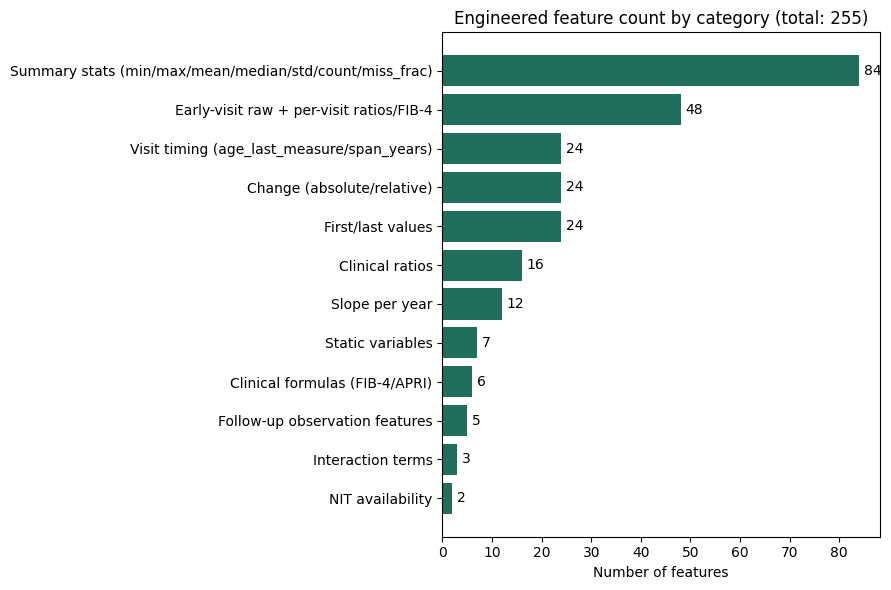

In [4]:
# Only plot categories with at least 1 feature, sorted descending
plot_counts = {k: v for k, v in counts.items() if v > 0}
plot_counts = dict(sorted(plot_counts.items(), key=lambda kv: kv[1]))

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(list(plot_counts.keys()), list(plot_counts.values()), color="#1F6F5C")
ax.set_xlabel("Number of features")
ax.set_title(f"Engineered feature count by category (total: {sum(plot_counts.values())})")
for bar, val in zip(bars, plot_counts.values()):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, str(val), va="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_feature_counts_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2: `fig_slope_illustrative_example.png`

Recreates the hypothetical rising versus stable GGT example from the chapter text, using the exact numbers stated there. This is purely illustrative and explicitly not real patient data.

Rising example slope: 4.10 U/L/year
Stable example slope: 0.05 U/L/year


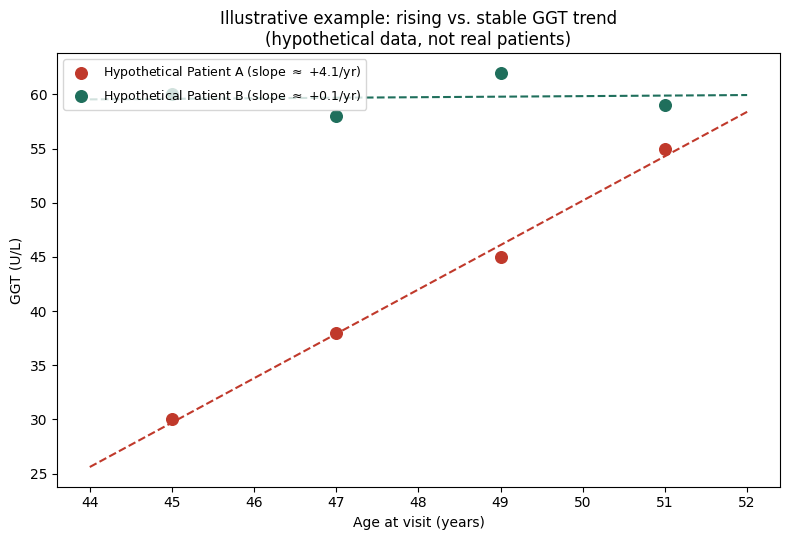

In [5]:
ages_rising = np.array([45, 47, 49, 51])
ggt_rising = np.array([30, 38, 45, 55])

ages_stable = np.array([45, 47, 49, 51])
ggt_stable = np.array([60, 58, 62, 59])

def ols_slope(x, y):
    xc = x - x.mean()
    return np.sum(xc * (y - y.mean())) / np.sum(xc ** 2)

slope_rising = ols_slope(ages_rising, ggt_rising)
slope_stable = ols_slope(ages_stable, ggt_stable)
print(f"Rising example slope: {slope_rising:.2f} U/L/year")
print(f"Stable example slope: {slope_stable:.2f} U/L/year")

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.scatter(ages_rising, ggt_rising, color="#C0392B", s=70, label=f"Hypothetical Patient A (slope $\\approx$ {slope_rising:+.1f}/yr)")
fit_x = np.array([44, 52])
fit_y_rising = ggt_rising.mean() + slope_rising * (fit_x - ages_rising.mean())
ax.plot(fit_x, fit_y_rising, color="#C0392B", linestyle="--")

ax.scatter(ages_stable, ggt_stable, color="#1F6F5C", s=70, label=f"Hypothetical Patient B (slope $\\approx$ {slope_stable:+.1f}/yr)")
fit_y_stable = ggt_stable.mean() + slope_stable * (fit_x - ages_stable.mean())
ax.plot(fit_x, fit_y_stable, color="#1F6F5C", linestyle="--")

ax.set_xlabel("Age at visit (years)")
ax.set_ylabel("GGT (U/L)")
ax.set_title("Illustrative example: rising vs. stable GGT trend\n(hypothetical data, not real patients)")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_slope_illustrative_example.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3: `fig_ast_alt_ratio_distribution.png`

Plots the real distribution of the AST/ALT ratio at the most recent visit across the training cohort, which directly supports the Xuan et al. 2024 citation on the clinical significance of AST/ALT in NAFLD.

Candidate AST/ALT ratio columns found: ['ast_alt_ratio_first', 'ast_alt_ratio_last', 'ast_alt_ratio_v1', 'ast_alt_ratio_v2', 'ast_alt_ratio_v3', 'ast_alt_ratio_v4']
n = 1091 patients with a computable AST/ALT ratio
median = 0.91, mean = 1.00


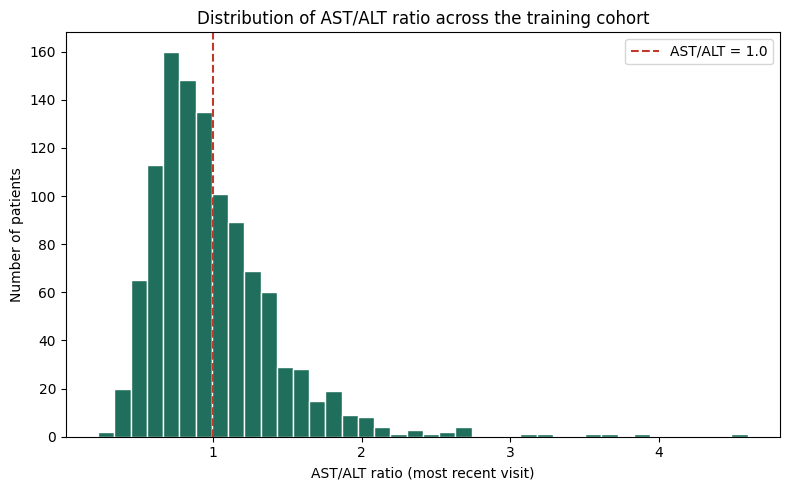

In [6]:
# ast_alt_ratio_last should already exist in X_hep from features.py's
# clinically meaningful derived features section -- confirm the exact
# column name before trusting this cell.
candidate_cols = [c for c in X_hep.columns if "ast_alt_ratio" in c.lower()]
print("Candidate AST/ALT ratio columns found:", candidate_cols)

ratio_col = "ast_alt_ratio_last"  # adjust if the printed list above shows a different exact name
assert ratio_col in X_hep.columns, f"'{ratio_col}' not found -- check candidate_cols above and fix this line"

ratio_values = X_hep[ratio_col].dropna()
print(f"n = {len(ratio_values)} patients with a computable AST/ALT ratio")
print(f"median = {ratio_values.median():.2f}, mean = {ratio_values.mean():.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ratio_values, bins=40, color="#1F6F5C", edgecolor="white")
ax.axvline(1.0, color="#C0392B", linestyle="--", label="AST/ALT = 1.0")
ax.set_xlabel("AST/ALT ratio (most recent visit)")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of AST/ALT ratio across the training cohort")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_ast_alt_ratio_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Done

All three PNGs are saved in `chapter6_figures/` at your repo root. Upload them directly into Overleaf's `Imagenes/Bitmap/` folder.

Before uploading Figure 1, check the printed 'Other/uncategorized' list, and fix the categorization logic first if it isn't empty. Before uploading Figure 3, check the printed `candidate_cols` list, and update `ratio_col` and rerun if `ast_alt_ratio_last` turns out not to be the real column name.